embeddings/s2_l2a_forest/fid_51/evt/20230823T142721_20230823T143116_T20LNR
56
FOREST · token 0 · celda 57  (fila 3, col 11)
[-0.48417118  1.73947906 -1.20512521 -0.55342275  1.89096987 -0.62746316
  1.05655479 -0.43633622 -0.97071415  0.78133482] ...


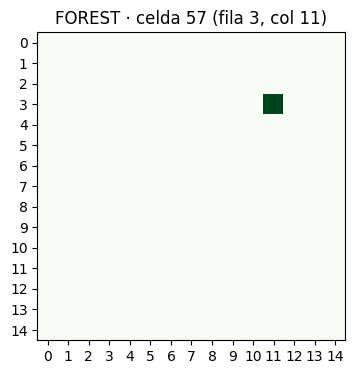

In [1]:
import numpy as np, pandas as pd, glob
import matplotlib.pyplot as plt

fid, tile, window, i = "51", "tile_0", "evt", 0   # i = token

d = glob.glob(f"embeddings/s2_l2a_forest/fid_{fid}/{window}/*")[0]
print(d)
locs = pd.read_csv(f"{d}/{tile}_locs.csv")
samp = pd.read_csv(f"{d}/{tile}_samples.csv").to_numpy()

cell = int(locs["cell"].iloc[i]) - 1          # 1-based -> 0-based
print(cell)
row, col = cell // 15, cell % 15
forest_vec = samp[i]

print(f"FOREST · token {i} · celda {cell+1}  (fila {row}, col {col})")
print(forest_vec[:10], "...")                 # first 10 values

grid = np.zeros((15, 15)); grid[row, col] = 1
plt.figure(figsize=(4, 4))
plt.imshow(grid, cmap="Greens")
plt.title(f"FOREST · celda {cell+1} (fila {row}, col {col})")
plt.xticks(range(15)); plt.yticks(range(15)); plt.grid(False)
plt.show()

embeddings/s2_l2a/fid_51/evt/20230823T142721_20230823T143116_T20LNR/tile_0.npy
optical · celda 57  (fila 3, col 11)
[-0.48417118  1.7394791  -1.2051252  -0.55342275  1.8909699  -0.62746316
  1.0565548  -0.43633622 -0.97071415  0.7813348 ] ...

same True


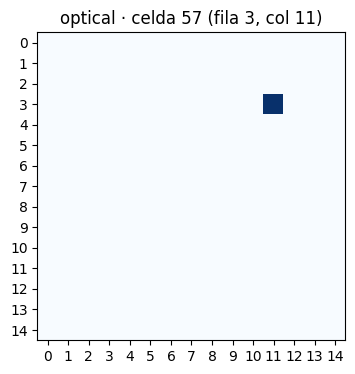

In [2]:
pair = d.split("/")[-1]                        # misma fecha
emb = np.load(f"embeddings/s2_l2a/fid_{fid}/{window}/{pair}/{tile}.npy").reshape(-1, 768)  # (225, 768)
print(f"embeddings/s2_l2a/fid_{fid}/{window}/{pair}/{tile}.npy")

optical_vec = emb[cell]                          # misma celda que forest
print(f"optical · celda {cell+1}  (fila {row}, col {col})")
print(optical_vec[:10], "...")                   # primeros 10 valores

print("\nsame", np.allclose(forest_vec, optical_vec, atol=1e-3, equal_nan=True))

grid = np.zeros((15, 15)); grid[row, col] = 1
plt.figure(figsize=(4, 4))
plt.imshow(grid, cmap="Blues")
plt.title(f"optical · celda {cell+1} (fila {row}, col {col})")
plt.xticks(range(15)); plt.yticks(range(15)); plt.grid(False)
plt.show()